<hr>
<div>
<h2>Initialize Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.</p>
</div>


In [1]:
# Standard Library
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing and Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

# Shared Table Styles
TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'left !important')],
    },
]

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

    
def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False


FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants and Data-Preparation Helpers
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}
DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0


def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: Africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out


def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Probability and Price-Shift Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>02 · The Magnitude Model</h1>
<p style="margin-bottom: 0;"><strong>Purpose:</strong> The State Model predicts which coverage level a trip lands in. To translate those probabilities into revenue, each trip also needs a revenue value for every state at each candidate price. Given the trip’s exposure, the states are treated as follows:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Level</th>
<th style="text-align: left;">Revenue treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">Zero</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">The scenario calculation assumes every traveling line and traveled day is covered</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Requires predicted day and line coverage</td>
</tr>
</tbody>
</table>
<p>The reconstructed <code>full</code> label permits day coverage between 70% and 100%, while the revenue calculation treats the state as coverage of every traveled day. This simplifying assumption is evaluated against observed full-state revenue in Section 5.</p>
<p>A ten-day trip with six covered days and one with two covered days both receive the <code>partial</code> label, assuming the same line coverage, but they generate materially different revenue. This section supplies that missing magnitude so the simulation can compute:</p>
    
$$
\mathbb{E}[R_i(m)]
=
\sum_s P_i(s \mid m)\times R_i(s,m)
$$
<p>where \(i\) identifies a trip, \(m\) is the candidate price multiplier, and \(s\) is the coverage state.</p>
<p><strong>Two magnitude components, fitted only on partial-coverage trips</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Model</th>
<th style="text-align: left;">Target</th>
<th style="text-align: left;">Form</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Day coverage</td>
<td style="text-align: left; vertical-align: top;"><code>days_bought / days_traveled</code></td>
<td style="text-align: left; vertical-align: top;">Exposure-weighted proportion model, weighted by <code>days_traveled</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Line coverage</td>
<td style="text-align: left; vertical-align: top;"><code>lines_active / lines_traveling</code></td>
<td style="text-align: left; vertical-align: top;">Exposure-weighted proportion model, weighted by <code>lines_traveling</code></td>
</tr>
</tbody>
</table>
<p><strong>The same separation principle as the State Model</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>Non-price features enter gradient-boosted regression models fitted on standard-price, partial-coverage trips. Price then enters through a sign-constrained parametric term.</li>
<li>The model tests whether higher prices are associated with lower retained coverage among partial-coverage trips. Where a price effect is estimated, the constraints prevent a higher price from implying greater retained coverage. The resulting response is checked for smoothness across the candidate-price grid.</li>
</ol>
<p><strong>One source of label contamination remains important throughout.</strong> The labels are reconstructed rather than directly observed. The data notebook measured the partial-coverage rule at approximately 77% precision, so approximately 23% of trips labeled <code>partial</code> are false positives rather than deliberate reductions. These cases are shallow by construction: they raise the observed retained-coverage fraction and pull the estimated reduction depth toward zero. Section 4 quantifies this bias and carries the resulting sensitivity into the simulation.</p>
</div>


In [18]:
# Load Inputs
trips = load_trips()
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

print(f'Trips Loaded: {len(trips):,}')


Trips Loaded: 94,579


<hr>
<div>
<h2>1 · Labels, Features, and the Split</h2>
<p><strong>Purpose:</strong> Reuses the State Model’s reconstructed labels, non-price feature definitions, and untouched test period so the State and Magnitude Models remain aligned. Because the Magnitude Model does not require a separate probability-calibration window, months 16 through 19 are included in its development period.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Alignment with the State Model.</strong> The following elements carry over unchanged from Notebook 01:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Source trip population</li>
<li>Label-reconstruction rule</li>
<li>Fifteen non-price feature definitions</li>
<li>Leakage exclusions</li>
<li>Expanding-window construction of <code>prior_trips</code></li>
<li>Months 20 through 23 as the untouched test period</li>
</ul>
<p>Reusing these definitions ensures that the state probabilities and conditional magnitudes refer to the same trips and coverage states.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Feature and Target Separation.</strong> The predictive feature matrix excludes label-defining fields, downstream outcomes, synthetic latent variables, and post-trip exposure fields.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>days_traveled</code> and <code>lines_traveling</code> are not predictors.</li>
<li>They are used only as denominators when constructing the day- and line-coverage targets and when calculating revenue.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Temporal Split.</strong> The Magnitude Model uses:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Slice</th>
<th style="text-align: left;">Months</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Development</td>
<td style="text-align: left; vertical-align: top;">0–19</td>
<td style="text-align: left; vertical-align: top;">Fit the non-price baseline and conditional price response</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Test</td>
<td style="text-align: left; vertical-align: top;">20–23</td>
<td style="text-align: left; vertical-align: top;">Evaluate magnitude predictions on untouched later trips</td>
</tr>
</tbody>
</table>
<p>Notebook 01 reserves months 16 through 19 for probability calibration. The Magnitude Model has no corresponding calibration stage, so those months remain available for development while the common test period stays untouched.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Conditional Modeling Population.</strong> Labels are reconstructed for all trips, but the Magnitude Model is fitted and evaluated only on trips labeled <code>partial</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The non-price baseline models use standard-price, partial-coverage trips from the development period.</li>
<li>The parametric price terms use all partial-coverage trips from the development period.</li>
<li>Final magnitude performance is evaluated on partial-coverage trips in the test period.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Synthetic-Data Assumption.</strong> The synthetic dataset represents a finalized historical snapshot, and all trips are treated as fully reported.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The reconstructed dataset contains 73,535 <code>full</code>, 11,478 <code>partial</code>, and 9,566 <code>null</code> trips.</li>
<li>The conditional modeling population contains 9,257 partial-coverage trips in the development period and 2,221 in the untouched test period.</li>
<li>These counts describe all partial-coverage trips. The non-price baseline models use the smaller standard-price subset, and sample adequacy is evaluated separately for the day- and line-coverage components because the two outcomes have different levels of observed support.</li>
</ol>
</div>


In [19]:
# Prepare Magnitude-Model Data
trips['y'] = reconstruct_label(trips)
trips['log_price'] = np.log(
    trips['price_multiplier']
)
trips['prior_trips'] = prior_trip_count(trips)

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

month = trips['month'].to_numpy()
tr = month <= 19
te = month >= 20
STD = trips['price_multiplier'].eq(1.0).to_numpy()

label_distribution = (
    trips['y']
    .value_counts()
    .reindex(CLASSES, fill_value = 0)
    .rename_axis('Coverage Level')
    .reset_index(name='Trips')
)

label_distribution['Share of Trips'] = (
    label_distribution['Trips']
    / label_distribution['Trips'].sum()
)

label_distribution['Coverage Level'] = (
    label_distribution['Coverage Level']
    .str.title()
)

display(
    label_distribution.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Trips': '{:.1%}',
    })
    .bar(
        subset = ['Share of Trips'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption('Reconstructed Coverage-State Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

samples = {
    'Train': ('0–19', tr),
    'Test': ('20–23', te),
}

sample_summary = pd.DataFrame([
    {
        'Sample': sample,
        'Months': months,
        'All Trips': mask.sum(),
        'Partial-Coverage Trips': (
            trips.loc[mask, 'y'] == 'partial'
        ).sum(),
        'Partial-Coverage Share': (
            trips.loc[mask, 'y'] == 'partial'
        ).mean(),
        'Standard-Price Partial Trips': (
            mask
            & STD
            & trips['y'].eq('partial').to_numpy()
        ).sum(),
    }
    for sample, (months, mask) in samples.items()
])

display(
    sample_summary.style
    .hide(axis = 'index')
    .format({
        'All Trips': '{:,.0f}',
        'Partial-Coverage Trips': '{:,.0f}',
        'Partial-Coverage Share': '{:.1%}',
        'Standard-Price Partial Trips': '{:,.0f}',
    })
    .bar(
        subset = ['Partial-Coverage Share'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption('Magnitude-Model Samples')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Coverage Level,Trips,Share of Trips
Null,"9,566",10.1%
Partial,"11,478",12.1%
Full,"73,535",77.7%


Sample,Months,All Trips,Partial-Coverage Trips,Partial-Coverage Share,Standard-Price Partial Trips
Train,0–19,"76,107","9,257",12.2%,"5,471"
Test,20–23,"18,472","2,221",12.0%,"1,973"


<hr>
<div>
<h2>2 · What Partial Coverage Actually Looks Like</h2>
<p><strong>Purpose:</strong> Examines the distribution of retained coverage among partial-coverage trips in the development period before fitting the Magnitude Model. The target’s shape helps determine whether a conditional-mean model is appropriate and whether the day- and line-coverage components require different treatment.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Development-Period Exploration.</strong> All exploratory summaries use months 0 through 19. Months 20 through 23 remain untouched for final evaluation.</li>
<li style="margin-bottom: 0.7em;"><strong>Retained Coverage and Reduction Depth.</strong> The fitted targets are retained-coverage proportions:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>day coverage = days_bought / days_traveled</code></li>
<li><code>line coverage = lines_active / lines_traveling</code></li>
</ul>
<p>A higher coverage value represents a shallower reduction. Reduction depth is the corresponding uncovered share:</p>
    
$$
\text{reduction depth}=1-\text{retained coverage}
$$</li>
<li style="margin-bottom: 0.7em;"><strong>Distributional Shape.</strong> Day coverage is a ratio of integer day counts and is therefore discrete rather than truly continuous.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The values may concentrate at common fractions such as one-third, one-half, and two-thirds.</li>
<li>The relevant question is whether retained coverage spans enough values for a conditional-mean model or whether its shape suggests a mixture, ordinal, or hurdle model.</li>
<li>A day-coverage value of 1.00 can occur among partial-coverage trips when all travel days are covered but fewer than all traveling lines are covered.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Frequency and Magnitude.</strong> The partial-coverage rate and retained coverage among partial trips answer different questions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The partial-coverage rate describes how frequently trips enter the <code>partial</code> state and is modeled in the State Model.</li>
<li>Conditional retained coverage describes how much coverage those trips purchase and is modeled in the Magnitude Model.</li>
<li>Comparing both measures across observed prices shows whether higher prices are descriptively associated only with more partial-coverage trips or also with deeper reductions.</li>
<li>These grouped comparisons are descriptive and do not isolate price from differences in customer, region, month, or trip composition.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Separate Day and Line Outcomes.</strong> Day and line coverage have materially different distributions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day reductions occur broadly enough to support a conditional magnitude model.</li>
<li>Line reductions are uncommon, so the line component has substantially less outcome variation.</li>
<li>Its price response must therefore be evaluated separately and interpreted cautiously if the coefficient is unstable or reaches a constraint boundary.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Chart Design.</strong> Frequency and retained coverage are displayed in separate stacked panels because they use different scales. This avoids the potentially misleading scale comparison created by a dual-axis chart.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Among development-period partial-coverage trips, median retained day coverage is <strong>0.50</strong>, with the 10th to 90th percentiles spanning <strong>0.25</strong> to <strong>0.67</strong>. Coverage spans multiple values but shows concentrations at fractions created by common trip lengths.</li>
<li>Across the observed price range in the development period, the partial-coverage rate changes from <strong>8.9%</strong> at the 0.90 multiplier to <strong>17.2%</strong> at the 1.20 multiplier, while mean retained day coverage among partial trips changes from <strong>0.56</strong> to <strong>0.40</strong>.</li>
<li>These descriptive patterns indicate whether higher observed prices are associated with both more partial-coverage trips and deeper reductions. They do not, by themselves, establish a price effect.</li>
<li>Line reductions occur in <strong>7.0%</strong> of development-period partial-coverage trips. Because this outcome is uncommon, the line-coverage model has less identifying information than the day-coverage model.</li>
</ol>
</div>


Partial-Coverage Trips,Mean Coverage,10th Percentile,Median,90th Percentile,Lines Also Reduced
"9,257",49.4%,25.0%,50.0%,66.7%,7.0%


Price Multiplier,Trips,Partial-Coverage Rate,Mean Coverage When Reducing,Mean Days Not Covered
0.90,"6,722",8.9%,56.0%,2.08
0.95,"7,099",10.0%,54.7%,2.29
1.00,"46,637",11.7%,51.0%,2.54
1.10,"9,150",15.0%,44.9%,3.02
1.20,"6,499",17.2%,39.9%,3.46


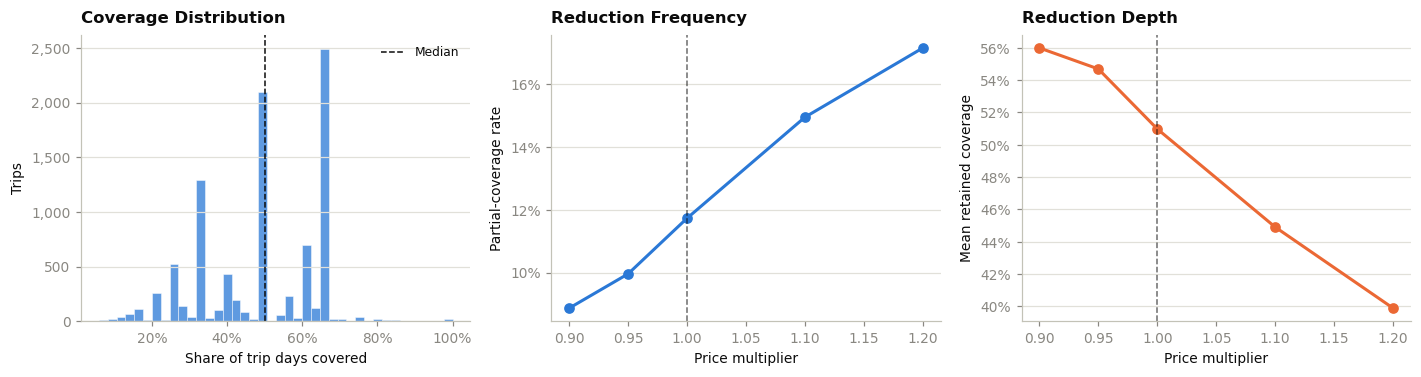

In [20]:
# Examine Reduction Shape
development_trips = trips[tr].copy()

reduced_trips = development_trips[
    development_trips['y'].eq('partial')
].copy()

reduced_trips['day_coverage'] = (
    reduced_trips['days_bought']
    / reduced_trips['days_traveled']
)

reduced_trips['line_coverage'] = (
    reduced_trips['lines_active']
    / reduced_trips['lines_traveling'].clip(lower = 1)
)

reduced_trips['days_not_covered'] = (
    reduced_trips['days_traveled']
    - reduced_trips['days_bought']
)

coverage_summary = pd.DataFrame({
    'Partial-Coverage Trips': [len(reduced_trips)],
    'Mean Coverage': [reduced_trips['day_coverage'].mean()],
    '10th Percentile': [
        reduced_trips['day_coverage'].quantile(0.10)
    ],
    'Median': [
        reduced_trips['day_coverage'].median()
    ],
    '90th Percentile': [
        reduced_trips['day_coverage'].quantile(0.90)
    ],
    'Lines Also Reduced': [
        reduced_trips['line_coverage'].lt(0.999).mean()
    ],
})

display(
    coverage_summary.style
    .hide(axis = 'index')
    .format({
        'Partial-Coverage Trips': '{:,.0f}',
        'Mean Coverage': '{:.1%}',
        '10th Percentile': '{:.1%}',
        'Median': '{:.1%}',
        '90th Percentile': '{:.1%}',
        'Lines Also Reduced': '{:.1%}',
    })
    .set_caption(
        'Development-Period Reduction Summary'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

depth = (
    development_trips
    .assign(
        is_partial = development_trips['y'].eq('partial')
    )
    .groupby('price_multiplier')
    .agg(
        Trips = ('trip_id', 'size'),
        Partial_Coverage_Rate = ('is_partial', 'mean'),
    )
)

reduction_depth = (
    reduced_trips
    .groupby('price_multiplier')
    .agg(
        Mean_Coverage_When_Reducing = (
            'day_coverage',
            'mean',
        ),
        Mean_Days_Not_Covered = (
            'days_not_covered',
            'mean',
        ),
    )
)

depth = (
    depth
    .join(reduction_depth)
    .rename_axis('Price Multiplier')
    .reset_index()
    .rename(columns = {
        'Partial_Coverage_Rate':
            'Partial-Coverage Rate',
        'Mean_Coverage_When_Reducing':
            'Mean Coverage When Reducing',
        'Mean_Days_Not_Covered':
            'Mean Days Not Covered',
    })
)

display(
    depth.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Trips': '{:,.0f}',
        'Partial-Coverage Rate': '{:.1%}',
        'Mean Coverage When Reducing': '{:.1%}',
        'Mean Days Not Covered': '{:.2f}',
    })
    .bar(
        subset = ['Partial-Coverage Rate'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .bar(
        subset = ['Mean Coverage When Reducing'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Reduction Frequency and Depth by Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize = (13, 3.5),
)

axes[0].hist(
    reduced_trips['day_coverage'],
    bins = 40,
    color = ACCENT,
    alpha = 0.75,
    edgecolor = SURFACE,
    linewidth = 0.4,
)

axes[0].axvline(
    reduced_trips['day_coverage'].median(),
    color = INK,
    linestyle = '--',
    linewidth = 1,
    label = 'Median',
)

axes[0].set(
    xlabel = 'Share of trip days covered',
    ylabel = 'Trips',
)

axes[0].set_title(
    'Coverage Distribution',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[0].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:,.0f}'
)

axes[0].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[0].legend(
    frameon = False,
    fontsize = 8,
)

axes[1].plot(
    depth['Price Multiplier'],
    depth['Partial-Coverage Rate'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[1].axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

axes[1].set(
    xlabel = 'Price multiplier',
    ylabel = 'Partial-coverage rate',
)

axes[1].set_title(
    'Reduction Frequency',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[1].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[2].plot(
    depth['Price Multiplier'],
    depth['Mean Coverage When Reducing'],
    marker = 'o',
    color = ACCENT2,
    linewidth = 2,
)

axes[2].axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

axes[2].set(
    xlabel = 'Price multiplier',
    ylabel = 'Mean retained coverage',
)

axes[2].set_title(
    'Reduction Depth',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[2].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[2].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · Reduction Depth</h2>
<p><strong>Purpose:</strong> Estimates retained day and line coverage among trips labeled <code>partial</code>. Reduction depth is derived as the complement of retained coverage, so a lower predicted coverage fraction represents a deeper reduction.</p>
    
$$
\text{reduction depth}
=
1-\text{retained coverage}
$$
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Two Coverage Components.</strong> A trip may reduce covered days, covered lines, or both.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day coverage: <code>days_bought / days_traveled</code></li>
<li>Line coverage: <code>lines_active / lines_traveling</code></li>
</ul>
<p>The model directly predicts these retained-coverage proportions. Their complements represent day- and line-reduction depth.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Exposure Weighting.</strong> Each target is weighted by its relevant denominator.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day coverage is weighted by <code>days_traveled</code>.</li>
<li>Line coverage is weighted by <code>lines_traveling</code>.</li>
<li>This gives observations with greater statistical exposure proportionately more influence during fitting.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Estimation Method.</strong> Each component uses a flexible non-price baseline followed by a constrained parametric price term.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The baseline stage fits a gradient-boosted regression model to the logit-transformed coverage proportion using exposure-weighted squared-error loss.</li>
<li>This is an approximation rather than a true binomial-deviance tree model.</li>
<li>The baseline model is fitted only on standard-price, partial-coverage trips.</li>
<li>The price stage is then fitted across all development-period partial-coverage trips using an exposure-weighted Bernoulli log-likelihood.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Connection to the State Model.</strong> The Magnitude Model uses the same separation principle as the State Model, although the two models do not have identical architectures.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Non-price features estimate the baseline relationship.</li>
<li>Price enters separately through a simple parametric term.</li>
<li>Fitting the baseline models across all prices could allow region and month to absorb variation intended for the price term.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Constraints.</strong> The base price coefficient is constrained to be nonpositive, preventing a higher price from increasing retained coverage for consumer accounts.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A business-account interaction is estimated separately.</li>
<li>The combined base and business effects are checked for every trip.</li>
<li>If more than 1% of trips have a positive combined price effect, the model is refitted with the business interaction fixed at zero.</li>
<li>The final fitted curves are checked across the complete candidate-price grid.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Boundary Interpretation.</strong> A coefficient at its imposed bound indicates that the constraint is active. It does not, by itself, prove that the parameter is unidentified.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A boundary estimate may reflect sparse outcome variation, instability, model misspecification, or an unconstrained optimum outside the permitted range.</li>
<li>Boundary estimates are therefore described as constraint-sensitive and are not interpreted as stable learned effects without additional validation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> Day and line coverage require separate evaluation because their outcome support differs materially.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The complete day model is compared with a constant prediction based on the development-period mean.</li>
<li>This comparison evaluates the combined tree and price model; it does not isolate the tree’s incremental contribution.</li>
<li>Establishing that contribution would require separate comparisons of constant, price-only, tree-only, and tree-plus-price specifications.</li>
<li>The line component requires its own held-out comparison of predicted and observed mean coverage, error, reduction frequency, performance by observed price, and sensitivity to the coefficient bounds.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><strong>Day Coverage.</strong> The base price coefficient is −3.34 and the business interaction is +1.14. Neither estimate reaches its imposed bound.</li>
<li>On held-out partial-coverage trips, the complete day model has an MAE of 0.124, compared with 0.123 for the constant benchmark. Its \(R^2\) is 0.003.</li>
<li>These results indicate essentially no trip-level predictive improvement over the constant benchmark. The current comparison does not establish whether the limited signal comes from the non-price tree, the price term, or their combination.</li>
<li><strong>Line Coverage.</strong> The base price coefficient reaches its −1.50 bound, and the business interaction reaches its −4.00 bound. Only 6.8% of partial-coverage trips reduce covered lines.</li>
<li>The line estimates are therefore constraint-sensitive and weakly supported. They should not be interpreted as a stable learned price response. The current implementation evaluates their aggregate revenue effect through the end-to-end check in Section 5 but does not separately validate line-coverage accuracy.</li>
<li><strong>Sign Check.</strong> No trip has a positive combined price effect for day coverage. The line-coverage effect is also nonpositive, although its direction and magnitude are largely determined by the active constraints.</li>
<li>Holding the test population fixed, predicted day coverage falls smoothly from approximately 0.57 at a 0.90 price multiplier to 0.38 at a 1.20 multiplier, with no monotonicity violations across the candidate-price grid.</li>
<li>This curve confirms that the fitted model obeys its imposed economic structure. It is not independent evidence that the true customer response is monotonic.</li>
</ol>
</div>


In [21]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)

    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fit_coverage(
    target_col,
    denom_col,
    label,
    lower_bound,
):
    partial = trips['y'].eq('partial').to_numpy()
    baseline_rows = partial & tr & STD
    price_rows = partial & tr

    denominator = (
        trips[denom_col]
        .to_numpy()
        .clip(1)
    )

    coverage = (
        trips[target_col].to_numpy()
        / denominator
    )

    base = HistGradientBoostingRegressor(
        max_iter = 300,
        learning_rate = 0.06,
        max_leaf_nodes = 15,
        min_samples_leaf = 40,
        l2_regularization = 1.0,
        early_stopping = True,
        validation_fraction = 0.15,
        random_state = 0,
    ).fit(
        X[baseline_rows],
        logit(coverage[baseline_rows]),
        sample_weight = denominator[baseline_rows],
    )

    baseline_prediction = base.predict(X[price_rows])
    log_price = trips.loc[
        price_rows, 'log_price'
    ].to_numpy()

    business = trips.loc[
        price_rows, 'is_business'
    ].to_numpy(dtype = float)

    observed = coverage[price_rows]
    weights = denominator[price_rows]

    def loss(theta):
        linear_prediction = (
            baseline_prediction
            + theta[0] * log_price
            + theta[1] * log_price * business
        )

        predicted = expit(linear_prediction)
        predicted = np.clip(
            predicted,
            1e-9,
            1 - 1e-9,
        )

        weighted_loss = weights * (
            observed * np.log(predicted)
            + (1 - observed) * np.log(1 - predicted)
        )

        return -weighted_loss.sum() / weights.sum()

    result = minimize(
        loss,
        np.zeros(2),
        method = 'L-BFGS-B',
        bounds = [
            (lower_bound, 0),
            (-4, 4),
        ],
        options = {'maxiter': 400},
    )

    if not result.success:
        raise RuntimeError(
            f'{label} fit did not converge: {result.message}'
        )

    theta = result.x
    net_effect = (
        theta[0]
        + theta[1] * business
    )

    interaction_retained = (
        (net_effect > 0).mean() <=  0.01
    )

    if not interaction_retained:
        result = minimize(
            loss,
            np.zeros(2),
            method = 'L-BFGS-B',
            bounds = [
                (lower_bound, 0),
                (0, 0),
            ],
            options = {'maxiter': 400},
        )

        if not result.success:
            raise RuntimeError(
                f'{label} constrained refit did not converge: '
                f'{result.message}'
            )

        theta = result.x
        net_effect = (
            theta[0]
            + theta[1] * business
        )

    diagnostics = {
        'Measure': label,
        'Baseline Trips': baseline_rows.sum(),
        'Price-Fit Trips': price_rows.sum(),
        'Price Coefficient': theta[0],
        'Business Interaction': theta[1],
        'Minimum Net Effect': net_effect.min(),
        'Median Net Effect': np.median(net_effect),
        'Maximum Net Effect': net_effect.max(),
        'Wrong-Signed Share': (net_effect > 0).mean(),
        'Interaction': (
            'Retained'
            if interaction_retained
            else 'Removed'
        ),
        'Bound Status': (
            'Active'
            if np.isclose(
                theta[0],
                lower_bound,
                atol = 1e-6,
            )
            else 'Not active'
        ),
    }

    return base, theta, diagnostics


partial = trips['y'].eq('partial')
line_cut_share = (
    partial
    & trips['lines_active'].lt(
        trips['lines_traveling']
    )
).sum() / max(partial.sum(), 1)

day_base, day_theta, day_diagnostics = fit_coverage(
    target_col = 'days_bought',
    denom_col = 'days_traveled',
    label = 'Day coverage',
    lower_bound = -5.0,
)

line_base, line_theta, line_diagnostics = fit_coverage(
    target_col = 'lines_active',
    denom_col = 'lines_traveling',
    label = 'Line coverage',
    lower_bound = -1.5,
)

fit_diagnostics = pd.DataFrame([
    day_diagnostics,
    line_diagnostics,
])

display(
    fit_diagnostics.style
    .hide(axis = 'index')
    .format({
        'Baseline Trips': '{:,.0f}',
        'Price-Fit Trips': '{:,.0f}',
        'Price Coefficient': '{:+.3f}',
        'Business Interaction': '{:+.3f}',
        'Minimum Net Effect': '{:+.3f}',
        'Median Net Effect': '{:+.3f}',
        'Maximum Net Effect': '{:+.3f}',
        'Wrong-Signed Share': '{:.1%}',
    })
    .bar(
        subset = ['Price Coefficient'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -5,
        vmax = 5,
    )
    .bar(
        subset = ['Business Interaction'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -4,
        vmax = 4,
    )
    .set_caption('Reduction-Depth Model Diagnostics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

support_summary = pd.DataFrame({
    'Measure': ['Partial trips with line reductions'],
    'Result': [line_cut_share],
    'Interpretation': [
        'Observed support for the line-coverage model'
    ],
})

display(
    support_summary.style
    .hide(axis = 'index')
    .format({'Result': '{:.1%}'})
    .bar(
        subset = ['Result'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption('Line-Reduction Data Support')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


def predict_coverage(
    base,
    theta,
    Xf,
    df,
    mult = None,
):
    if mult is None:
        log_price = df['log_price'].to_numpy()
    else:
        log_price = np.full(
            len(df),
            np.log(float(mult)),
        )

    linear_prediction = (
        base.predict(Xf)
        + theta[0] * log_price
        + theta[1]
        * log_price
        * df['is_business'].to_numpy(dtype = float)
    )

    return np.clip(
        expit(linear_prediction),
        0.02,
        1.0,
    )


Measure,Baseline Trips,Price-Fit Trips,Price Coefficient,Business Interaction,Minimum Net Effect,Median Net Effect,Maximum Net Effect,Wrong-Signed Share,Interaction,Bound Status
Day coverage,"5,471","9,257",-3.336,+1.142,-3.336,-2.194,-2.194,0.0%,Retained,Not active
Line coverage,"5,471","9,257",-1.500,-4.000,-5.500,-5.500,-1.500,0.0%,Retained,Active


Measure,Result,Interpretation
Partial trips with line reductions,6.8%,Observed support for the line-coverage model


Method,MAE,R²,Mean Prediction,Observed Mean,Mean Gap,Assessment
Reduction-depth model,0.1239,0.0032,49.6%,50.7%,-1.1%,Review
Train-mean benchmark,0.1228,-0.0083,49.4%,50.7%,-1.4%,Benchmark


Test Trips,Mean Prediction,Observed Mean,Mean Gap,MAE,Trips Reducing Lines
"2,221",100.0%,97.1%,+2.8%,0.0288,6.1%


Price Multiplier,Predicted Day Coverage
0.90,56.9%
1.00,49.9%
1.20,38.0%


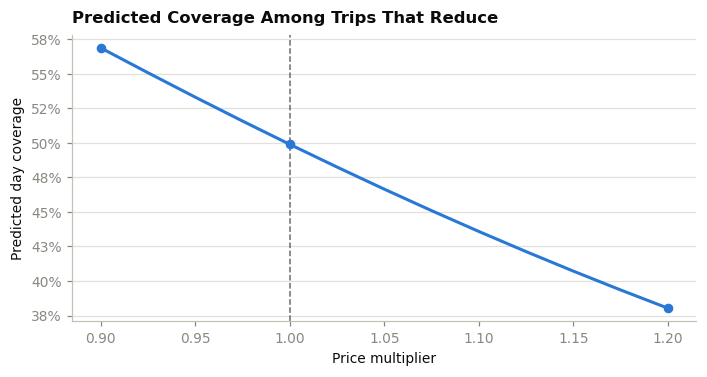

In [22]:
# Validate Reduction-Depth Models
partial_test = (
    trips['y'].eq('partial')
    & te
).to_numpy()

test_partial_trips = trips[partial_test]

observed_day_coverage = (
    test_partial_trips['days_bought']
    / test_partial_trips['days_traveled']
).to_numpy()

predicted_day_coverage = predict_coverage(
    day_base,
    day_theta,
    X[partial_test],
    test_partial_trips,
)

train_partial = (
    trips['y'].eq('partial')
    & tr
)

train_mean_coverage = (
    trips.loc[train_partial, 'days_bought']
    / trips.loc[train_partial, 'days_traveled']
).mean()

constant_prediction = np.full_like(
    observed_day_coverage,
    train_mean_coverage,
)

model_mae = mean_absolute_error(
    observed_day_coverage,
    predicted_day_coverage,
)

constant_mae = mean_absolute_error(
    observed_day_coverage,
    constant_prediction,
)

day_model_passes = model_mae < constant_mae

day_validation = pd.DataFrame({
    'Method': [
        'Reduction-depth model',
        'Train-mean benchmark',
    ],
    'MAE': [
        model_mae,
        constant_mae,
    ],
    'R²': [
        r2_score(
            observed_day_coverage,
            predicted_day_coverage,
        ),
        r2_score(
            observed_day_coverage,
            constant_prediction,
        ),
    ],
    'Mean Prediction': [
        predicted_day_coverage.mean(),
        train_mean_coverage,
    ],
    'Observed Mean': [
        observed_day_coverage.mean(),
        observed_day_coverage.mean(),
    ],
    'Mean Gap': [
        predicted_day_coverage.mean()
        - observed_day_coverage.mean(),
        train_mean_coverage
        - observed_day_coverage.mean(),
    ],
    'Assessment': [
        'Pass' if day_model_passes else 'Review',
        'Benchmark',
    ],
})

display(
    day_validation.style
    .hide(axis = 'index')
    .format({
        'MAE': '{:.4f}',
        'R²': '{:.4f}',
        'Mean Prediction': '{:.1%}',
        'Observed Mean': '{:.1%}',
        'Mean Gap': '{:+.1%}',
    })
    .bar(
        subset = ['Mean Gap'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.05,
        vmax = 0.05,
    )
    .set_caption(
        'Held-Out Day-Coverage Validation'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Assessment'],
        **{
            'color': (
                '#237a3b'
                if day_model_passes
                else RED
            ),
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

observed_line_coverage = (
    test_partial_trips['lines_active']
    / test_partial_trips[
        'lines_traveling'
    ].clip(lower = 1)
).to_numpy()

predicted_line_coverage = predict_coverage(
    line_base,
    np.zeros(2),
    X[partial_test],
    test_partial_trips,
)

line_validation = pd.DataFrame({
    'Test Trips': [len(test_partial_trips)],
    'Mean Prediction': [
        predicted_line_coverage.mean()
    ],
    'Observed Mean': [
        observed_line_coverage.mean()
    ],
    'Mean Gap': [
        predicted_line_coverage.mean()
        - observed_line_coverage.mean()
    ],
    'MAE': [
        mean_absolute_error(
            observed_line_coverage,
            predicted_line_coverage,
        )
    ],
    'Trips Reducing Lines': [
        (
            observed_line_coverage < 0.999
        ).mean()
    ],
})

display(
    line_validation.style
    .hide(axis = 'index')
    .format({
        'Test Trips': '{:,.0f}',
        'Mean Prediction': '{:.1%}',
        'Observed Mean': '{:.1%}',
        'Mean Gap': '{:+.1%}',
        'MAE': '{:.4f}',
        'Trips Reducing Lines': '{:.1%}',
    })
    .bar(
        subset = ['Trips Reducing Lines'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption(
        'Held-Out Line-Coverage Validation'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

coverage_curve = np.array([
    predict_coverage(
        day_base,
        day_theta,
        X[partial_test],
        test_partial_trips,
        multiplier,
    ).mean()
    for multiplier in GRID
])

monotonicity_violations = int(
    (np.diff(coverage_curve) > 1e-9).sum()
)

assert monotonicity_violations ==  0, (
    'predicted coverage increases somewhere '
    'in the price sweep'
)

selected_prices = [0.90, 1.00, 1.20]

curve_summary = pd.DataFrame({
    'Price Multiplier': selected_prices,
    'Predicted Day Coverage': [
        np.interp(
            multiplier,
            GRID,
            coverage_curve,
        )
        for multiplier in selected_prices
    ],
})

display(
    curve_summary.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Predicted Day Coverage': '{:.1%}',
    })
    .bar(
        subset = ['Predicted Day Coverage'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Predicted Day Coverage at Selected Prices'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (6.5, 3.5),
)

ax.plot(
    GRID,
    coverage_curve,
    color = ACCENT,
    linewidth = 2,
)

ax.scatter(
    selected_prices,
    [
        np.interp(
            multiplier,
            GRID,
            coverage_curve,
        )
        for multiplier in selected_prices
    ],
    color = ACCENT,
    s = 28,
    zorder = 3,
)

ax.axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = 'Predicted day coverage',
)

ax.set_title(
    'Predicted Coverage Among Trips That Reduce',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>4 · Partial-Label False Positives and Reduction-Depth Sensitivity</h2>
<p><strong>Purpose:</strong> Measures how false positives in the reconstructed <code>partial</code> label affect estimated day-reduction depth and defines a stronger-depth sensitivity for the revenue simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Scope of the Diagnostic.</strong> This section evaluates false positives among trips labeled <code>partial</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not measure false negatives, confusion between every pair of states, or the overall accuracy of the State Model.</li>
<li>It measures how including trips that are not truly partial changes the conditional day-coverage target used by the Magnitude Model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Use of Synthetic Truth.</strong> The synthetic dataset contains a latent state that identifies which labeled partial trips were generated from the true partial state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This latent field is excluded from both predictive models.</li>
<li>It is used only for this diagnostic and the resulting simulation sensitivity.</li>
<li>In an operational dataset without a latent state, this source of label error would not be directly measurable.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Development-Period Estimation.</strong> The sensitivity factor is estimated using partial-coverage trips from months 0 through 19.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Months 20 through 23 remain outside the calculation.</li>
<li>The test period may be used to report whether the estimated bias remains similar over time, but it is not used to construct the simulation factor.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Bias Direction.</strong> The Magnitude Model predicts retained day coverage:
    
$$
\text{day coverage}
=
\frac{\text{days bought}}{\text{days traveled}}
$$
<p>Day-reduction depth is its complement:</p>
    
$$
\text{day-reduction depth}
=
1-\text{day coverage}
$$
    
<p>False-positive partial labels represent shallower reductions on average than trips generated from the true partial state. Including them raises observed retained coverage, reduces measured reduction depth, and can bias expected partial-state revenue upward.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Weighting.</strong> The diagnostic reports two versions of the difference:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A trip-weighted comparison, which gives every partial-coverage trip equal weight</li>
<li>A day-exposure-weighted comparison, which weights trips by <code>days_traveled</code></li>
</ul>
<p>The day-exposure-weighted result is used for the simulation sensitivity because it is more closely aligned with the Magnitude Model’s fitting objective and the revenue associated with covered days.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Sensitivity Calculation.</strong> The stronger-depth multiplier is calculated as:
    
$$
\text{depth sensitivity}
=
\frac{\text{mean day-reduction depth among true partial trips}}
 {\text{mean day-reduction depth among all labeled partial trips}}
$$<br>

<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>depth_scale = 1.00</code> uses the depth estimated from the reconstructed labels.</li>
<li><code>depth_scale =</code> <strong>1.04</strong> applies the stronger day-reduction sensitivity estimated from the synthetic latent state.</li>
<li>The factor is applied only to day-reduction depth.</li>
<li>Line coverage is left unchanged because the day-derived factor does not establish an equivalent bias in the line component.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The multiplier is a sensitivity assumption, not a correction to known truth or a statistical bound on the outcome. It shows how the revenue result changes if true partial trips reduce day coverage more deeply than the reconstructed labels suggest.</li>
<li style="margin-bottom: 0.7em;"><strong>Uncertainty.</strong> A bootstrap interval is calculated for the development-period depth-sensitivity multiplier. This interval describes sampling uncertainty in the diagnostic; it does not capture uncertainty in the synthetic data-generating assumptions.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">In the development period, the reconstructed partial-coverage rule has a precision of <strong>77.4%</strong>: <strong>2,093</strong> of <strong>9,257</strong> labeled partial trips are false positives.</li>
<li style="margin-bottom: 0.7em;">False-positive partial trips have higher retained day coverage than trips generated from the true partial state:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>True partial trips: <strong>0.4648</strong></li>
<li>All labeled partial trips: <strong>0.4935</strong></li>
<li>False-positive partial trips: <strong>0.5918</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The trip-weighted difference in retained coverage is <strong>2.9 percentage points</strong>.</li>
<li style="margin-bottom: 0.7em;">The day-exposure-weighted mean reduction depth is <strong>0.5433</strong> among true partial trips and <strong>0.5220</strong> among all labeled partial trips.</li>
<li style="margin-bottom: 0.7em;">The resulting stronger-depth sensitivity multiplier is <strong>1.04×</strong>, with a 95% bootstrap interval of <strong>1.03× to 1.05×</strong>.</li>
<li style="margin-bottom: 0.7em;">This multiplier applies only to predicted day-reduction depth. It is carried into the simulation alongside the unadjusted <code>1.00</code> case so the revenue effect of partial-label false positives remains visible.</li>
</ol>
</div>


In [23]:
# Measure Label Contamination
development_mask = tr

truth_state = trips['state'].replace({
    'substitutes': 'null',
    'leaves': 'null',
})

labeled_partial = (
    trips['y'].eq('partial').to_numpy()
    & development_mask
)

true_partial = (
    labeled_partial
    & truth_state.eq('partial').to_numpy()
)

false_positive = (
    labeled_partial
    & ~truth_state.eq('partial').to_numpy()
)

day_coverage = (
    trips['days_bought']
    / trips['days_traveled']
).to_numpy()

day_weights = (
    trips['days_traveled']
    .to_numpy(dtype = float)
    .clip(1)
)

PRECISION = (
    true_partial.sum()
    / max(labeled_partial.sum(), 1)
)

contamination_summary = pd.DataFrame({
    'Classification': [
        'All labeled partial',
        'True partial',
        'False positive',
    ],
    'Trips': [
        labeled_partial.sum(),
        true_partial.sum(),
        false_positive.sum(),
    ],
    'Share of Labeled Partial': [
        1.0,
        PRECISION,
        1 - PRECISION,
    ],
    'Mean Retained Coverage': [
        day_coverage[labeled_partial].mean(),
        day_coverage[true_partial].mean(),
        (
            day_coverage[false_positive].mean()
            if false_positive.any()
            else np.nan
        ),
    ],
})

display(
    contamination_summary.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Labeled Partial': '{:.1%}',
        'Mean Retained Coverage': '{:.1%}',
    })
    .bar(
        subset = ['Share of Labeled Partial'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .bar(
        subset = ['Mean Retained Coverage'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Development-Period Partial-Label Contamination'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


def weighted_depth(mask):
    return float(
        np.average(
            1 - day_coverage[mask],
            weights = day_weights[mask],
        )
    )


true_depth = weighted_depth(true_partial)
labeled_depth = weighted_depth(labeled_partial)
DEPTH_BIAS = true_depth / labeled_depth

bootstrap_rng = np.random.default_rng(0)
true_indices = np.where(true_partial)[0]
labeled_indices = np.where(labeled_partial)[0]

bootstrap_ratios = np.array([
    weighted_depth(
        bootstrap_rng.choice(
            true_indices,
            len(true_indices),
            replace = True,
        )
    )
    / weighted_depth(
        bootstrap_rng.choice(
            labeled_indices,
            len(labeled_indices),
            replace = True,
        )
    )
    for _ in range(2000)
])

BOOTSTRAP_LOWER, BOOTSTRAP_UPPER = np.percentile(
    bootstrap_ratios,
    [2.5, 97.5],
)

sensitivity_summary = pd.DataFrame({
    'Label Precision': [PRECISION],
    'True-Partial Depth': [true_depth],
    'All-Labeled Depth': [labeled_depth],
    'Depth Multiplier': [DEPTH_BIAS],
    '95% Bootstrap Interval': [
        f'{BOOTSTRAP_LOWER:.2f}×–{BOOTSTRAP_UPPER:.2f}×'
    ],
    'Bootstrap Replicates': [len(bootstrap_ratios)],
})

display(
    sensitivity_summary.style
    .hide(axis = 'index')
    .format({
        'Label Precision': '{:.1%}',
        'True-Partial Depth': '{:.1%}',
        'All-Labeled Depth': '{:.1%}',
        'Depth Multiplier': '{:.2f}×',
        'Bootstrap Replicates': '{:,.0f}',
    })
    .set_caption(
        'Stronger-Depth Sensitivity Estimate'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Depth Multiplier'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


Classification,Trips,Share of Labeled Partial,Mean Retained Coverage
All labeled partial,"9,257",100.0%,49.4%
True partial,"7,164",77.4%,46.5%
False positive,"2,093",22.6%,59.2%


Label Precision,True-Partial Depth,All-Labeled Depth,Depth Multiplier,95% Bootstrap Interval,Bootstrap Replicates
77.4%,54.3%,52.2%,1.04×,1.03×–1.05×,"2,000"


<hr>
<div>
<h2>5 · Revenue per State</h2>
<p><strong>Purpose:</strong> Applies the pricing identity to each coverage state and candidate price, producing the revenue lookup table used by the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Pricing Identity.</strong> Revenue depends on the number of covered lines, covered days, and the candidate price multiplier:
    
$$
R(L,D,m)
=
\begin{cases}
0, & L=0,\\[4pt]
\left[10+5(L-1)\right]Dm, & L>0,
\end{cases}
$$
<p style="margin-bottom: 0;">where:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>\(L\) is the number of covered lines.</li>
<li>\(D\) is the number of covered days.</li>
<li>\(m\) is the candidate price multiplier.</li>
<li>The first covered line costs &#36;10 per covered day at the standard price.</li>
<li>Each additional covered line costs &#36;5 per covered day at the standard price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Treatment by State.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Coverage state</th>
<th style="text-align: left;">Covered lines</th>
<th style="text-align: left;">Covered days</th>
<th style="text-align: left;">Revenue treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">0</td>
<td style="text-align: left; vertical-align: top;">0</td>
<td style="text-align: left; vertical-align: top;">Revenue is fixed at zero</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">All traveling lines</td>
<td style="text-align: left; vertical-align: top;">All traveled days</td>
<td style="text-align: left; vertical-align: top;">Revenue is calculated from the trip’s complete exposure</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Predicted from line coverage</td>
<td style="text-align: left; vertical-align: top;">Predicted from day coverage</td>
<td style="text-align: left; vertical-align: top;">Revenue is calculated from the predicted retained coverage</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Full-State Approximation.</strong> The reconstructed <code>full</code> label requires at least 70% day coverage and coverage of every traveling line. The scenario calculation nevertheless assigns every traveled day and line to the <code>full</code> state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This creates a deterministic revenue rule for simulation.</li>
<li>It is a simplifying assumption because some historically labeled <code>full</code> trips purchased fewer than all traveled days.</li>
<li>Its empirical effect is evaluated by comparing predicted and observed full-state revenue on the same held-out trips.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Partial-State Quantities.</strong> For a trip assigned to the <code>partial</code> state:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Predicted day coverage is multiplied by <code>days_traveled</code>.</li>
<li>Predicted line coverage is multiplied by <code>lines_traveling</code>.</li>
<li>The resulting quantities are rounded to whole days and lines.</li>
<li>A minimum of one covered day and one covered line is enforced so the partial-state calculation does not collapse into the <code>null</code> state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Use of Exposure Fields.</strong> <code>days_traveled</code> and <code>lines_traveling</code> are post-trip exposure values used to construct the revenue scenarios.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They are not predictors in either the State or Magnitude Model.</li>
<li>The synthetic dataset is treated as a finalized historical snapshot in which these exposure values are fully observed.</li>
<li>The forward simulation carries these values as exposure assumptions rather than predicted customer features.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Interface.</strong> <code>revenue_by_state</code> produces one revenue value for every trip, coverage state, and candidate price.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Model 02 evaluates the function across the complete price grid.</li>
<li>The resulting revenue-by-state table is exported.</li>
<li>The simulation loads this table rather than calling the fitted Magnitude Model directly, keeping the state-revenue definitions consistent across notebooks.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>State-Level Validation.</strong> Predicted and observed revenue are compared on identical held-out populations.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Predicted <code>partial</code> revenue is compared with observed revenue among trips actually labeled <code>partial</code>.</li>
<li>Predicted <code>full</code> revenue is compared with observed revenue among trips actually labeled <code>full</code>.</li>
<li>Null-state revenue is verified to equal zero.</li>
<li>Dollar and percentage errors are reported for each state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>End-to-End Validation.</strong> State probabilities and state-specific revenue are combined on the untouched test period:
    
$$
\widehat{R}_i
=
\sum_s
\widehat{P}_i(s\mid m_i)\,
\widehat{R}_i(s,m_i)
$$
<p>where \(m_i\) is trip \(i\)’s observed price multiplier.</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Both the state probabilities and revenue values are evaluated at the same observed price for every trip.</li>
<li>Expected and observed revenue are compared in aggregate and by observed price level.</li>
<li>Results are also reviewed separately for consumer and business accounts.</li>
<li>A bootstrap interval is reported for the aggregate percentage error.</li>
<li>Interpretation is based on the magnitude and consistency of the errors rather than an acceptance threshold chosen after viewing the results.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">At the standard price, mean predicted revenue among held-out trips actually observed in each state is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>null</code>: &#36;0.00</li>
<li><code>partial</code>: <strong>&#36;30.84</strong></li>
<li><code>full</code>: <strong>&#36;67.30</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">Mean observed revenue on those same trips is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>null</code>: &#36;0.00</li>
<li><code>partial</code>: <strong>&#36;29.29</strong></li>
<li><code>full</code>: <strong>&#36;65.96</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The corresponding state-level errors are:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>partial</code>: <strong>&#36;1.54</strong>, or <strong>5.3%</strong></li>
<li><code>full</code>: <strong>&#36;1.33</strong>, or <strong>2.0%</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">On <strong>18,472</strong> held-out trips, with probabilities and revenue aligned to each trip’s observed price, expected total revenue is <strong>&#36;1,040,593</strong>, compared with observed revenue of <strong>&#36;1,015,446</strong>.</li>
<li style="margin-bottom: 0.7em;">The aggregate error is <strong>+2.48%</strong>, with a 95% bootstrap interval of <strong>+1.7% to +3.3%</strong>.</li>
<li style="margin-bottom: 0.7em;">By observed price level the aggregate error is +2.2% at 1.00x, +2.4% at 0.95x, and +7.2% at 1.10x; by account type it is +2.4% for business and +2.5% for consumer accounts. The 1.10x figure rests on far fewer test trips and should be read with that in mind.</li>
<li style="margin-bottom: 0.7em;">The difference between predicted and observed full-state revenue quantifies the effect of treating every <code>full</code> trip as covering all traveled days. The difference is <strong>2.0%</strong> on the held-out full-state population.</li>
</ol>
</div>


In [24]:
# Compute Revenue by Coverage State
def revenue_by_state(
    Xf,
    df,
    mult = 1.0,
    depth_scale = 1.0,
):
    """Return potential trip revenue for each coverage state."""
    lines_traveled = df[
        'lines_traveling'
    ].to_numpy(dtype = float)

    days_traveled = df[
        'days_traveled'
    ].to_numpy(dtype = float)

    def calculate_revenue(lines, days):
        lines = np.maximum(lines, 0)

        return np.where(
            lines > 0,
            (
                PRICE_FIRST
                + PRICE_ADDL * (lines - 1)
            )
            * days
            * mult,
            0.0,
        )

    day_coverage = predict_coverage(
        day_base,
        day_theta,
        Xf,
        df,
        mult,
    )

    line_coverage = predict_coverage(
        line_base,
        np.zeros(2),
        Xf,
        df,
        mult,
    )

    day_coverage = np.clip(
        1
        - depth_scale
        * (1 - day_coverage),
        0.02,
        1.0,
    )

    partial_lines = np.maximum(
        np.round(
            lines_traveled
            * line_coverage
        ),
        1,
    )

    partial_days = np.maximum(
        np.round(
            days_traveled
            * day_coverage
        ),
        1,
    )

    revenue = np.zeros(
        (len(df), len(CLASSES))
    )

    revenue[:, IDX['null']] = 0.0

    revenue[:, IDX['full']] = calculate_revenue(
        lines_traveled,
        days_traveled,
    )

    revenue[:, IDX['partial']] = calculate_revenue(
        partial_lines,
        partial_days,
    )

    assert np.isfinite(revenue).all(), (
        'non-finite values in state-level revenue'
    )

    assert (revenue >=  0).all(), (
        'negative values in state-level revenue'
    )

    return revenue


standard_price_test = te & STD

potential_revenue = revenue_by_state(
    X[standard_price_test],
    trips[standard_price_test],
    mult = 1.0,
)

observed_state = trips.loc[
    standard_price_test,
    'y',
].to_numpy()

validation_rows = []

for coverage_class in CLASSES:
    state_mask = observed_state ==  coverage_class

    predicted_revenue = (
        potential_revenue[
            state_mask,
            IDX[coverage_class],
        ].mean()
        if state_mask.any()
        else np.nan
    )

    observed_revenue = trips.loc[
        standard_price_test
        & trips['y'].eq(
            coverage_class
        ).to_numpy(),
        'pass_revenue',
    ].mean()

    dollar_error = (
        predicted_revenue
        - observed_revenue
    )

    relative_error = (
        dollar_error / observed_revenue
        if observed_revenue > 0
        else np.nan
    )

    validation_rows.append({
        'Coverage Level': coverage_class.title(),
        'Trips': state_mask.sum(),
        'Predicted Revenue': predicted_revenue,
        'Observed Revenue': observed_revenue,
        'Revenue Error': dollar_error,
        'Relative Error': relative_error,
    })

revenue_validation = pd.DataFrame(
    validation_rows
)

display(
    revenue_validation.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Predicted Revenue': '{:,.2f}',
        'Observed Revenue': '{:,.2f}',
        'Revenue Error': '{:+,.2f}',
        'Relative Error': '{:+.1%}',
    }, na_rep = '—')
    .bar(
        subset = ['Revenue Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -25,
        vmax = 25,
    )
    .bar(
        subset = ['Relative Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        'Standard-Price Test Validation: Mean Revenue per Trip (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Coverage Level,Trips,Predicted Revenue,Observed Revenue,Revenue Error,Relative Error
Null,"1,650",0.00,0.00,+0.00,—
Partial,"1,973",30.84,29.29,+1.54,+5.3%
Full,"12,988",67.30,65.96,+1.33,+2.0%


In [25]:
# End-to-End Revenue Check
scored = load('scored_trips')

scored_test = (
    scored.loc[
        scored['slice'].eq('test')
    ]
    .set_index('trip_id')
)

test_trip_ids = trips.loc[
    te,
    'trip_id',
]

common_trip_ids = test_trip_ids[
    test_trip_ids.isin(scored_test.index)
]

if common_trip_ids.empty:
    REV_ERROR = np.nan

    raise ValueError(
        'scored_trips does not overlap the test window; '
        'rerun the State Model section'
    )

matched_test = (
    trips['trip_id']
    .isin(common_trip_ids)
    .to_numpy()
    & te
)

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

matched_trip_ids = trips.loc[
    matched_test,
    'trip_id',
]

probabilities = scored_test.loc[
    matched_trip_ids,
    probability_columns,
].to_numpy()

X_matched = X[matched_test]
trips_matched = trips[matched_test]
observed_prices = trips_matched[
    'price_multiplier'
].to_numpy()

state_revenue = np.zeros(
    (len(trips_matched), len(CLASSES))
)

for multiplier in np.unique(observed_prices):
    price_mask = observed_prices ==  multiplier

    state_revenue[price_mask] = revenue_by_state(
        X_matched.iloc[price_mask],
        trips_matched.iloc[price_mask],
        float(multiplier),
    )

expected_revenue = (
    probabilities
    * state_revenue
).sum(axis = 1)

observed_revenue = trips_matched[
    'pass_revenue'
].to_numpy()

assert np.isfinite(expected_revenue).all(), (
    'non-finite expected revenue in end-to-end check'
)

assert observed_revenue.sum() > 0, (
    'observed test revenue must be positive'
)

REV_ERROR = float(
    expected_revenue.sum()
    / observed_revenue.sum()
    - 1
)

revenue_summary = pd.DataFrame({
    'Measure': [
        'Total revenue',
        'Revenue per trip',
    ],
    'Expected Revenue': [
        expected_revenue.sum(),
        expected_revenue.mean(),
    ],
    'Observed Revenue': [
        observed_revenue.sum(),
        observed_revenue.mean(),
    ],
})

revenue_summary['Difference'] = (
    revenue_summary['Expected Revenue']
    - revenue_summary['Observed Revenue']
)

revenue_summary['Relative Error'] = (
    revenue_summary['Difference']
    / revenue_summary['Observed Revenue']
)

display(
    revenue_summary.style
    .hide(axis = 'index')
    .format({
        'Expected Revenue': '{:,.2f}',
        'Observed Revenue': '{:,.2f}',
        'Difference': '{:+,.2f}',
        'Relative Error': '{:+.1%}',
    })
    .bar(
        subset = ['Relative Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        f'End-to-End Test Revenue Reconciliation — '
        f'{len(expected_revenue):,} Trips'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

bootstrap_rng = np.random.default_rng(0)

bootstrap_errors = np.empty(2000)

for iteration in range(len(bootstrap_errors)):
    sample = bootstrap_rng.integers(
        0,
        len(expected_revenue),
        len(expected_revenue),
    )

    bootstrap_errors[iteration] = (
        expected_revenue[sample].sum()
        / observed_revenue[sample].sum()
        - 1
    )

REV_ERROR_LOWER, REV_ERROR_UPPER = np.percentile(
    bootstrap_errors,
    [2.5, 97.5],
)

uncertainty_summary = pd.DataFrame({
    'Aggregate Error': [REV_ERROR],
    'Lower Bound': [REV_ERROR_LOWER],
    'Upper Bound': [REV_ERROR_UPPER],
    'Bootstrap Replicates': [
        len(bootstrap_errors)
    ],
    'Resampling Unit': ['Trip'],
})

display(
    uncertainty_summary.style
    .hide(axis = 'index')
    .format({
        'Aggregate Error': '{:+.1%}',
        'Lower Bound': '{:+.1%}',
        'Upper Bound': '{:+.1%}',
        'Bootstrap Replicates': '{:,.0f}',
    })
    .set_caption(
        'Trip-Level Bootstrap Interval for Aggregate Revenue Error'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Aggregate Error'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

reconciliation_data = trips_matched.assign(
    expected_revenue = expected_revenue,
    observed_revenue = observed_revenue,
    account_type = np.where(
        trips_matched['is_business'],
        'Business',
        'Consumer',
    ),
)

by_price = (
    reconciliation_data
    .groupby('price_multiplier')
    .agg(
        Trips = ('trip_id', 'size'),
        Expected_Revenue = (
            'expected_revenue',
            'sum',
        ),
        Observed_Revenue = (
            'observed_revenue',
            'sum',
        ),
    )
    .reset_index()
    .rename(columns = {
        'price_multiplier': 'Group',
        'Expected_Revenue': 'Expected Revenue',
        'Observed_Revenue': 'Observed Revenue',
    })
)

by_price.insert(
    0,
    'Dimension',
    'Observed Price',
)

by_price['Group'] = by_price['Group'].map(
    lambda value: f'{value:.2f}'
)

by_account_type = (
    reconciliation_data
    .groupby('account_type')
    .agg(
        Trips = ('trip_id', 'size'),
        Expected_Revenue = (
            'expected_revenue',
            'sum',
        ),
        Observed_Revenue = (
            'observed_revenue',
            'sum',
        ),
    )
    .reset_index()
    .rename(columns = {
        'account_type': 'Group',
        'Expected_Revenue': 'Expected Revenue',
        'Observed_Revenue': 'Observed Revenue',
    })
)

by_account_type.insert(
    0,
    'Dimension',
    'Account Type',
)

revenue_breakdown = pd.concat(
    [
        by_price,
        by_account_type,
    ],
    ignore_index = True,
)

revenue_breakdown['Revenue Error'] = (
    revenue_breakdown['Expected Revenue']
    / revenue_breakdown['Observed Revenue']
    - 1
)

display(
    revenue_breakdown.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Expected Revenue': '{:,.0f}',
        'Observed Revenue': '{:,.0f}',
        'Revenue Error': '{:+.1%}',
    })
    .bar(
        subset = ['Revenue Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        'Revenue Reconciliation by Price and Account Type'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Measure,Expected Revenue,Observed Revenue,Difference,Relative Error
Total revenue,"1,040,615.39","1,015,445.75","+25,169.64",+2.5%
Revenue per trip,56.33,54.97,+1.36,+2.5%


Aggregate Error,Lower Bound,Upper Bound,Bootstrap Replicates,Resampling Unit
+2.5%,+1.7%,+3.3%,"2,000",Trip


Dimension,Group,Trips,Expected Revenue,Observed Revenue,Revenue Error
Observed Price,0.95,946,"50,332","49,129",+2.4%
Observed Price,1.00,"16,611","934,814","914,545",+2.2%
Observed Price,1.10,915,"55,469","51,772",+7.1%
Account Type,Business,"10,492","435,967","425,636",+2.4%
Account Type,Consumer,"7,980","604,649","589,809",+2.5%


<hr>
<div>
<h2>6 · The Revenue Curve</h2>
<p><strong>Purpose:</strong> Provides a deterministic preview of modeled revenue across the candidate-price range by combining each forward-panel trip’s final State Model scenario probabilities with its state-specific revenue values. The forward-panel population (the most recent 12 months) and its observed seasonal and macroeconomic characteristics remain fixed; future uncertainty is introduced later in the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Calculation.</strong> Expected revenue is calculated separately for every trip and then aggregated:
    
$$
\widehat{R}(m)
=
\sum_i\sum_s
\widehat{P}_i(s\mid m)\,
\widehat{R}_i(s,m)
$$
<p style="margin-bottom: 0;">where:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>\(i\) identifies a trip.</li>
<li>\(s\) identifies a coverage state.</li>
<li>\(m\) is the candidate price multiplier.</li>
<li>\(\widehat{P}_i(s\mid m)\) is trip \(i\)’s final calibrated probability of state \(s\) at price \(m\).</li>
<li>\(\widehat{R}_i(s,m)\) is trip \(i\)’s modeled revenue under state \(s\) at the same price.</li>
</ul>
<p>Each trip’s probability vector is multiplied by its own state-revenue vector before aggregation. This preserves the relationship between predicted behavior and revenue exposure.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Consistent Model Inputs.</strong> Every candidate price uses:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The final State Model scorer</li>
<li>The fitted day- and line-coverage components</li>
<li>The state-specific revenue rules from Section 5</li>
<li>The same fixed forward-panel population</li>
</ul>
<p>Price is the only scenario input changed across the curve.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Deterministic Preview.</strong> The curve is a model-based scenario calculation rather than the final forecast.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not simulate future macroeconomic paths, trip-volume uncertainty, correlated behavioral outcomes, or sampling variation.</li>
<li>It holds the forward-panel population’s month, macroeconomic, customer, and trip characteristics fixed.</li>
<li>The 12-month simulation adds the forward-looking uncertainty required for the final revenue estimates.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Depth Assumption.</strong> This preview uses <code>depth_scale = 1.00</code>, representing the magnitude estimated from the reconstructed partial-coverage labels.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The stronger day-reduction sensitivity from Section 4 is evaluated separately in the simulation.</li>
<li>The two cases are sensitivity scenarios, not corrected and uncorrected truth or statistical bounds.</li>
<li>The depth-sensitivity factor applies only to day-reduction depth; line coverage remains unchanged.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Candidate-Price Range.</strong> Each trip is scored from a 0.90 to 1.20 price multiplier.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This is the permitted scenario range, not a claim that every price was historically observed across the complete customer population.</li>
<li>Historical price variation was concentrated in particular regions and periods.</li>
<li>Applying every candidate price to the fixed forward-panel population is therefore a counterfactual modeling exercise.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Curve Validation.</strong> The completed curve is checked for:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Finite, nonnegative revenue at every candidate price</li>
<li>Unexpected discontinuities or reversals</li>
<li>Sensitivity to the spacing of the price grid</li>
<li>Consistency between the State Model probabilities and revenue values used at each price</li>
</ul>
<p>Small slope changes or plateaus may result from probability calibration and the rounding of predicted covered days and lines. These are not automatically treated as model failures.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Boundary Interpretation.</strong> If modeled revenue is highest at the 1.20 multiplier and remains increasing at that point:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>1.20 is the best evaluated price within the approved candidate range.</li>
<li>The study does not identify an interior optimum.</li>
<li>The result does not establish that 1.20 is the true revenue-maximizing price.</li>
<li>The model provides no basis for recommending a price above the approved ceiling.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The best evaluated price within the candidate range is <strong>1.20</strong>.</li>
<li>Modeled revenue at the standard price is <strong>&#36;2,956,579</strong>, compared with <strong>&#36;3,317,045</strong> at the best evaluated price.</li>
<li>The corresponding modeled increase is <strong>&#36;360,466</strong>, or <strong>12.2%</strong>.</li>
<li>At the upper boundary, modeled revenue is <strong>still increasing</strong>.</li>
<li>The curve contains <strong>0</strong> unexpected direction reversals and <strong>0</strong> material discontinuities.</li>
<li>The curve is evaluated at the 13 exported scenario prices, the same grid the 12-month simulation uses.</li>
<li>This deterministic preview uses the as-fitted response and rises to the 1.20 boundary. The full 12-month simulation's joint stronger-response case turns over at 1.15 (Section 5); the preview reflects only the as-fitted case and is not the study's recommendation.</li>
</ol>
</div>


Price Multiplier,Revenue,Change vs. Standard,Incremental Revenue
0.900,"2,735,955",-7.5%,"-220,623"
0.925,"2,792,857",-5.5%,"-163,721"
0.950,"2,848,898",-3.6%,"-107,680"
0.975,"2,904,083",-1.8%,"-52,495"
1.000,"2,956,579",+0.0%,+0
1.025,"2,994,157",+1.3%,"+37,578"
1.050,"3,047,134",+3.1%,"+90,556"
1.075,"3,099,623",+4.8%,"+143,044"
1.100,"3,150,623",+6.6%,"+194,045"
1.125,"3,197,192",+8.1%,"+240,613"


Best Evaluated Price,Standard Revenue,Best Revenue,Revenue Lift,Declining Steps,Direction Reversals,Large Jumps,Curve Status
1.200,"2,956,579","3,317,045",+12.2%,0,0,0,Still increasing at upper boundary


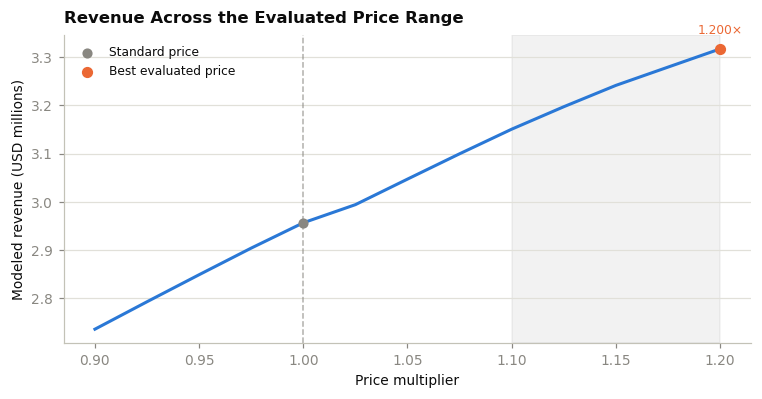

In [26]:
# Build Deterministic Revenue Curve
scenario_probabilities = load(
    'sim_prob_scenarios'
)

scenario_probabilities = scenario_probabilities.loc[
    scenario_probabilities[
        'response_scenario'
    ].eq('base')
].copy()

scenario_probabilities['price_multiplier'] = (
    scenario_probabilities[
        'price_multiplier'
    ].round(4)
)

CURVE_GRID = np.sort(
    scenario_probabilities[
        'price_multiplier'
    ].unique()
)

forward_mask = (
    trips['month']
    >=  trips['month'].max() - 11
).to_numpy()

forward_trip_ids = trips.loc[
    forward_mask,
    'trip_id',
]

common_trip_ids = forward_trip_ids[
    forward_trip_ids.isin(
        scenario_probabilities[
            'trip_id'
        ].unique()
    )
]

if common_trip_ids.empty:
    raise ValueError(
        'sim_prob_scenarios does not overlap the forward panel'
    )

matched_forward = (
    trips['trip_id']
    .isin(common_trip_ids)
    .to_numpy()
    & forward_mask
)

matched_trip_ids = trips.loc[
    matched_forward,
    'trip_id',
].to_numpy()

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

probability_index = (
    scenario_probabilities
    .set_index([
        'price_multiplier',
        'trip_id',
    ])
    .sort_index()
)

curve_rows = []

for multiplier in CURVE_GRID:
    probabilities = (
        probability_index
        .loc[
            round(float(multiplier), 4),
            probability_columns,
        ]
        .reindex(matched_trip_ids)
        .to_numpy()
    )

    if not np.isfinite(probabilities).all():
        raise ValueError(
            f'missing scenario probabilities at '
            f'{multiplier:.4f}'
        )

    state_revenue = revenue_by_state(
        X[matched_forward],
        trips[matched_forward],
        float(multiplier),
    )

    curve_rows.append({
        'Price Multiplier': multiplier,
        'Revenue': float(
            (
                state_revenue
                * probabilities
            ).sum()
        ),
    })

curve = (
    pd.DataFrame(curve_rows)
    .set_index('Price Multiplier')
)

standard_revenue = curve.loc[
    1.0,
    'Revenue',
]

curve['Change vs. Standard'] = (
    curve['Revenue']
    / standard_revenue
    - 1
)

curve['Incremental Revenue'] = (
    curve['Revenue']
    - standard_revenue
)

curve_display = (
    curve
    .reset_index()
)

display(
    curve_display.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        'Revenue': '{:,.0f}',
        'Change vs. Standard': '{:+.1%}',
        'Incremental Revenue': '{:+,.0f}',
    })
    .bar(
        subset = ['Change vs. Standard'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.10,
        vmax = 0.25,
    )
    .set_caption(
        'Deterministic Forward-Panel Revenue Preview (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

best_price = float(
    curve['Revenue'].idxmax()
)

best_revenue = float(
    curve.loc[
        best_price,
        'Revenue',
    ]
)

revenue_steps = (
    curve['Revenue']
    .diff()
    .dropna()
    .to_numpy()
)

declining_steps = int(
    (revenue_steps < 0).sum()
)

nonzero_directions = np.sign(
    revenue_steps[
        np.abs(revenue_steps) > 1e-9
    ]
)

direction_reversals = int(
    (
        nonzero_directions[1:]
        !=  nonzero_directions[:-1]
    ).sum()
)

median_step = np.median(
    np.abs(revenue_steps)
)

large_jumps = (
    int(
        (
            np.abs(revenue_steps)
            > 3 * median_step
        ).sum()
    )
    if median_step > 0
    else 0
)

at_upper_boundary = bool(
    np.isclose(
        best_price,
        CURVE_GRID[-1],
    )
)

curve_summary = pd.DataFrame({
    'Best Evaluated Price': [best_price],
    'Standard Revenue': [standard_revenue],
    'Best Revenue': [best_revenue],
    'Revenue Lift': [
        best_revenue
        / standard_revenue
        - 1
    ],
    'Declining Steps': [declining_steps],
    'Direction Reversals': [direction_reversals],
    'Large Jumps': [large_jumps],
    'Curve Status': [
        (
            'Still increasing at upper boundary'
            if at_upper_boundary
            else 'Interior turnover observed'
        )
    ],
})

display(
    curve_summary.style
    .hide(axis = 'index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Standard Revenue': '{:,.0f}',
        'Best Revenue': '{:,.0f}',
        'Revenue Lift': '{:+.1%}',
        'Declining Steps': '{:,.0f}',
        'Direction Reversals': '{:,.0f}',
        'Large Jumps': '{:,.0f}',
    })
    .set_caption(
        'Deterministic Revenue-Curve Summary'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7, 3.7),
)

revenue_millions = (
    curve['Revenue']
    / 1e6
)

ax.plot(
    curve.index,
    revenue_millions,
    color = ACCENT,
    linewidth = 2,
)

ax.scatter(
    [1.0],
    [standard_revenue / 1e6],
    color = MUTED,
    s = 32,
    zorder = 3,
    label = 'Standard price',
)

ax.scatter(
    [best_price],
    [best_revenue / 1e6],
    color = ACCENT2,
    s = 40,
    zorder = 4,
    label = 'Best evaluated price',
)

ax.axvline(
    1.0,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.65,
)

ax.axvspan(
    1.10,
    1.20,
    color = INK,
    alpha = 0.05,
)

ax.annotate(
    f'{best_price:.3f}×',
    xy = (
        best_price,
        best_revenue / 1e6,
    ),
    xytext = (0, 10),
    textcoords = 'offset points',
    ha = 'center',
    color = ACCENT2,
    fontsize = 8,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = 'Modeled revenue (USD millions)',
)

ax.set_title(
    'Revenue Across the Evaluated Price Range',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>7 · Model Outputs and Simulation Handoff</h2>
<p><strong>Purpose:</strong> Publishes the trip-level magnitude diagnostics, state-specific revenue values, the deterministic revenue preview, and model metadata used for reporting and the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Exported Artifacts.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Role</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>trip_magnitudes</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip at its observed price</td>
<td style="text-align: left; vertical-align: top;">Auditable record of predicted day and line coverage</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>revenue_by_state</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip and candidate price (reported depth only)</td>
<td style="text-align: left; vertical-align: top;">Full-book state revenue used by the deterministic preview and §04</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>sim_revenue_scenarios</code></td>
<td style="text-align: left; vertical-align: top;">One row per forward-panel trip, candidate price, and depth scenario</td>
<td style="text-align: left; vertical-align: top;">The state-revenue table the 12-month simulation loads</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>deterministic_revenue_curve</code></td>
<td style="text-align: left; vertical-align: top;">One row per candidate price</td>
<td style="text-align: left; vertical-align: top;">Stores the deterministic revenue preview from Section 6</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>magnitude_meta</code></td>
<td style="text-align: left; vertical-align: top;">One row per metadata field</td>
<td style="text-align: left; vertical-align: top;">Documents assumptions, coefficients, sensitivities, and the revenue error</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Inputs.</strong> The simulation loads <code>sim_revenue_scenarios</code> and <code>magnitude_meta</code>. It reshapes the table rather than calling the fitted Magnitude Model directly, so the two sections cannot apply different revenue definitions. <code>trip_magnitudes</code>, <code>revenue_by_state</code>, and <code>deterministic_revenue_curve</code> support review and reporting but are not required to run the simulation.</li>
<li style="margin-bottom: 0.7em;"><strong>Depth Scenarios.</strong> <code>sim_revenue_scenarios</code> carries two day-depth assumptions:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>reported</code>: <code>depth_scale = 1.00</code>.</li>
<li><code>stronger</code>: the day-depth sensitivity estimated in Section 4.</li>
</ul>
<p>The sensitivity is applied only to predicted day-reduction depth before covered days are rounded. Predicted line coverage is unchanged.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Tables.</strong> For every trip and candidate price, each revenue table includes the synthetic trip identifier, <code>price_multiplier</code>, and revenue under <code>null</code>, <code>partial</code>, and <code>full</code> (with <code>depth_scenario</code> in <code>sim_revenue_scenarios</code>). Null-state revenue is zero at every price and scenario.</li>
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Diagnostics.</strong> <code>trip_magnitudes</code> records trip and account identifiers, observed month and price, and predicted day and line coverage at the observed price. These are audit fields, not predictive inputs.</li>
<li style="margin-bottom: 0.7em;"><strong>Deterministic Preview.</strong> <code>deterministic_revenue_curve</code> has one row per candidate price, each value formed from trip-level state probabilities times trip-level state revenue (see Section 6). It is a preview, not the simulated forecast.</li>
<li style="margin-bottom: 0.7em;"><strong>Metadata.</strong> <code>magnitude_meta</code> records the day-depth sensitivity, the day and line base price coefficients, the held-out revenue error, and the random seed.</li>
<li style="margin-bottom: 0.7em;"><strong>Revenue-Error Diagnostic.</strong> The held-out revenue error from Section 5 is exported for transparency. It describes how closely the combined models reproduce observed test-period revenue; it is not applied as a correction and is not a statistical bound.</li>
<li style="margin-bottom: 0.7em;"><strong>File Format.</strong> Parquet is preferred (it preserves types and handles the large revenue tables efficiently); CSV is the fallback for this portfolio study.</li>
<li style="margin-bottom: 0.7em;"><strong>Export Step.</strong> <code>save_tables</code> writes the five tables and reports their row counts. Column-level and read-back validation are not performed in code.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Five artifacts are written: <code>trip_magnitudes</code> (94,579 rows), <code>revenue_by_state</code> (1,229,527), <code>sim_revenue_scenarios</code> (1,365,000), <code>deterministic_revenue_curve</code> (13), and <code>magnitude_meta</code> (5).</li>
<li><code>sim_revenue_scenarios</code> covers the 52,500 forward-panel trips at 13 candidate prices under two depth scenarios.</li>
<li>The <code>reported</code> scenario uses <code>depth_scale = 1.00</code>; the <code>stronger</code> scenario uses <code>depth_scale = 1.04</code>, with a 95% bootstrap interval of 1.03 to 1.05.</li>
<li>The held-out revenue error is +2.5%, with a 95% bootstrap interval of about +1.7% to +3.3%. It is retained as a diagnostic and not applied to the simulated revenue.</li>
</ol>
</div>


In [27]:
# Export Magnitude-Model Results
mag = trips[[
    'trip_id',
    'account_id',
    'month',
    'price_multiplier',
]].copy()

mag['pred_day_coverage'] = predict_coverage(
    day_base,
    day_theta,
    X,
    trips,
)

mag['pred_line_coverage'] = predict_coverage(
    line_base,
    np.zeros(2),
    X,
    trips,
)

revenue_frames = []

for multiplier in GRID:
    state_revenue = revenue_by_state(
        X,
        trips,
        float(multiplier),
    )

    revenue_frames.append(
        pd.DataFrame({
            'trip_id': trips[
                'trip_id'
            ].to_numpy(),
            'price_multiplier': float(multiplier),
            **{
                f'rev_{coverage_class}':
                    state_revenue[:, i]
                for i, coverage_class
                in enumerate(CLASSES)
            },
        })
    )

revenue_by_state_table = pd.concat(
    revenue_frames,
    ignore_index = True,
)

meta = pd.DataFrame({
    'key': [
        'depth_bias',
        'revenue_error',
        'day_price_coef',
        'line_price_coef',
        'line_price_coef_used',
    ],
    'value': [
        DEPTH_BIAS,
        REV_ERROR,
        float(day_theta[0]),
        float(line_theta[0]),
        0.0,
    ],
})

meta_display = pd.DataFrame({
    'Parameter': [
        'Stronger-depth multiplier',
        'End-to-end revenue error',
        'Day-coverage price coefficient',
        'Estimated line-price coefficient',
        'Line-price coefficient used',
    ],
    'Value': [
        f'{DEPTH_BIAS:.2f}×',
        f'{REV_ERROR:+.1%}',
        f'{day_theta[0]:+.3f}',
        f'{line_theta[0]:+.3f}',
        '0.000',
    ],
    'Interpretation': [
        'Applied in the stronger-depth sensitivity',
        'Measured on held-out trips',
        'Used in production revenue calculations',
        'Retained for diagnostic reporting',
        'Constraint-sensitive price term excluded',
    ],
})

display(
    meta_display.style
    .hide(axis = 'index')
    .set_caption('Magnitude-Model Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

if not np.isfinite(DEPTH_BIAS):
    raise ValueError(
        'a finite depth-bias multiplier is required '
        'for the stronger-depth scenario'
    )

probability_scenarios = load(
    'sim_prob_scenarios'
)

SIM_GRID = np.sort(
    probability_scenarios[
        'price_multiplier'
    ].round(4).unique()
)

forward_mask = (
    trips['month']
    >=  trips['month'].max() - 11
).to_numpy()

X_forward = X[forward_mask]
trips_forward = trips[forward_mask]
forward_trip_ids = trips_forward[
    'trip_id'
].to_numpy()

scenario_frames = []

# Mirror of the stronger depth case below the fitted depth: the scenario tool's
# "Lower" sensitivity setting. No diagnostic motivates it; it shows the other direction.
LOWER_DEPTH_BIAS = 2.0 - DEPTH_BIAS
assert LOWER_DEPTH_BIAS > 0, 'lower depth scale must stay positive'

for depth_scale, scenario_name in [
    (1.0, 'reported'),
    (LOWER_DEPTH_BIAS, 'lower'),
    (DEPTH_BIAS, 'stronger'),
]:
    for multiplier in SIM_GRID:
        state_revenue = revenue_by_state(
            X_forward,
            trips_forward,
            float(multiplier),
            depth_scale = depth_scale,
        )

        scenario_frames.append(
            pd.DataFrame({
                'trip_id': forward_trip_ids,
                'price_multiplier': float(multiplier),
                'depth_scenario': scenario_name,
                **{
                    f'rev_{coverage_class}':
                        state_revenue[:, i]
                    for i, coverage_class
                    in enumerate(CLASSES)
                },
            })
        )

sim_revenue_scenarios = pd.concat(
    scenario_frames,
    ignore_index = True,
)

probability_grid = set(
    probability_scenarios[
        'price_multiplier'
    ].round(4)
)

revenue_grid = set(
    sim_revenue_scenarios[
        'price_multiplier'
    ].round(4)
)

assert probability_grid ==  revenue_grid, (
    'probability and revenue scenario grids do not match'
)

assert (
    sim_revenue_scenarios[
        ['rev_null', 'rev_partial', 'rev_full']
    ]
    .notna()
    .all()
    .all()
), 'missing values in simulation revenue scenarios'

assert (
    sim_revenue_scenarios[
        ['rev_null', 'rev_partial', 'rev_full']
    ]
    .ge(0)
    .all()
    .all()
), 'negative values in simulation revenue scenarios'

deterministic_revenue_curve = (
    curve
    .reset_index()
    .rename(columns = {
        'Price Multiplier': 'price_multiplier',
        'Revenue': 'revenue',
        'Change vs. Standard': 'vs_standard',
        'Incremental Revenue': 'incremental_revenue',
    })
)

export_summary = save_tables(
    {
        'trip_magnitudes': mag,
        'revenue_by_state': revenue_by_state_table,
        'sim_revenue_scenarios': sim_revenue_scenarios,
        'deterministic_revenue_curve':
            deterministic_revenue_curve,
        'magnitude_meta': meta,
    },
    with_cols = True,
)

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns = {
        'rows': 'Rows',
        'cols': 'Columns',
    })
)

display(
    export_summary.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Columns': '{:,.0f}',
    })
    .set_caption('Exported Magnitude-Model Tables')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Parameter,Value,Interpretation
Stronger-depth multiplier,1.04×,Applied in the stronger-depth sensitivity
End-to-end revenue error,+2.5%,Measured on held-out trips
Day-coverage price coefficient,-3.336,Used in production revenue calculations
Estimated line-price coefficient,-1.500,Retained for diagnostic reporting
Line-price coefficient used,0.000,Constraint-sensitive price term excluded


File,Rows,Columns
trip_magnitudes.parquet,"94,579",6
revenue_by_state.parquet,"1,229,527",5
sim_revenue_scenarios.parquet,"2,047,500",6
deterministic_revenue_curve.parquet,13,4
magnitude_meta.parquet,5,2
